# Data Cleaning and Visualizations
This notebook demonstrates handling missing values, outliers, and duplicates using Pandas, Matplotlib, and Seaborn.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load the dataset
df = pd.read_csv('WomensClothingE-CommerceReviews.csv', engine='c', skipinitialspace=True)
df.columns = df.columns.str.strip()
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws ...,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy! ...,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt ...,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## 1. Handle Missing Values

In [7]:
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing text columns with placeholders
df['Title'] = df['Title'].fillna('No Title')
df['Review Text'] = df['Review Text'].fillna('No Review')

# Fill categorical columns with mode
for col in ['Division Name', 'Department Name', 'Class Name']:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

Missing values after cleaning:
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64


## 2. Handle Duplicates

In [8]:
print(f"Number of duplicate rows before: {df.duplicated().sum()}")

# Drop duplicates
df = df.drop_duplicates()

print(f"Number of duplicate rows after: {df.duplicated().sum()}")

Number of duplicate rows before: 21
Number of duplicate rows after: 0


## 3. Handle Outliers

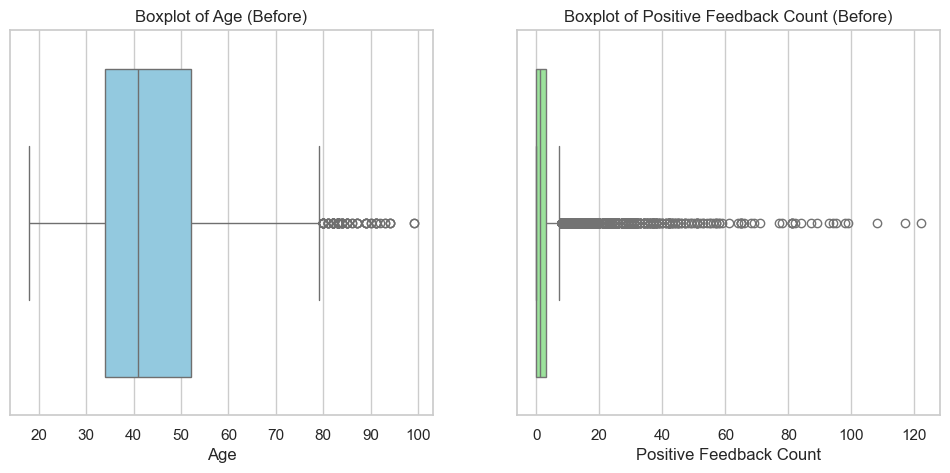

Data shape before removing outliers: (23465, 10)
Data shape after removing outliers: (21222, 10)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x=df['Age'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Age (Before)')

sns.boxplot(x=df['Positive Feedback Count'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Positive Feedback Count (Before)')
plt.show()

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Remove outliers in Age and Positive Feedback Count
df_cleaned = remove_outliers_iqr(df, 'Age')
df_cleaned = remove_outliers_iqr(df_cleaned, 'Positive Feedback Count')

print(f"Data shape before removing outliers: {df.shape}")
print(f"Data shape after removing outliers: {df_cleaned.shape}")

## 4. Visual Reports of Key Findings

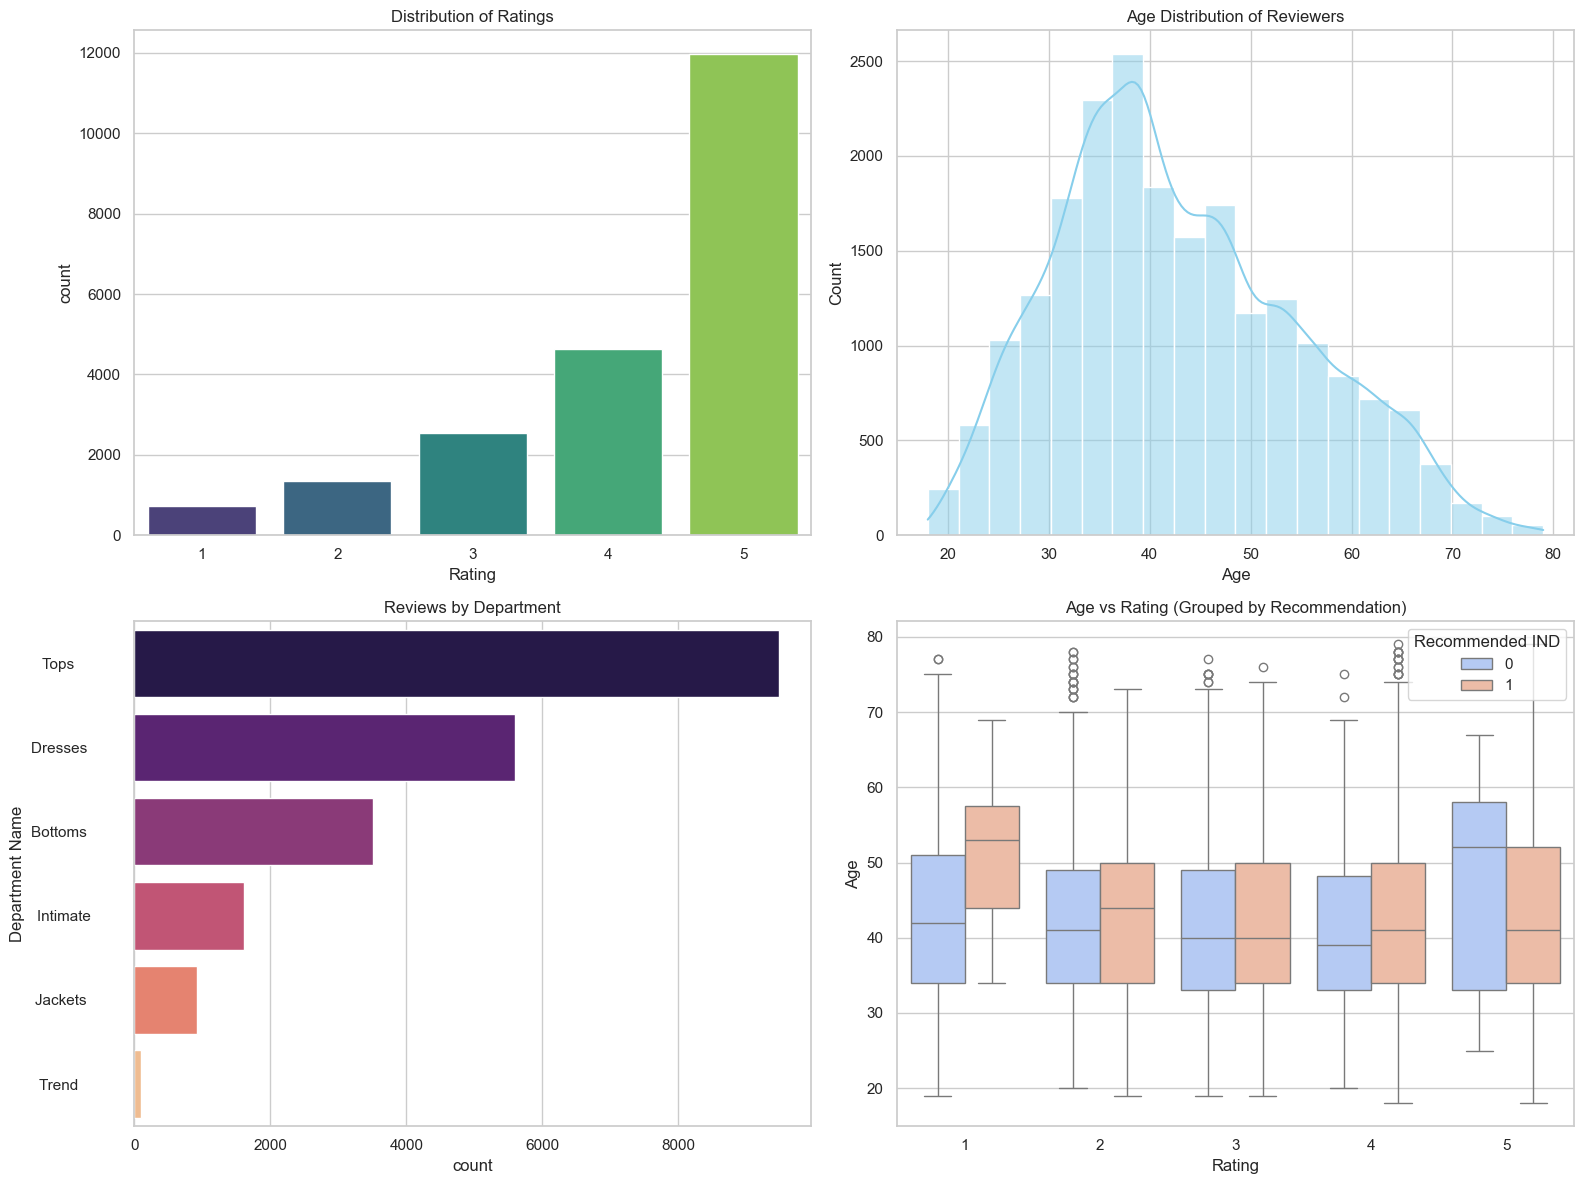

In [10]:
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(16, 12))

# 1. Distribution of Ratings
plt.subplot(2, 2, 1)
sns.countplot(data=df_cleaned, x='Rating', palette='viridis')
plt.title('Distribution of Ratings')

# 2. Age Distribution
plt.subplot(2, 2, 2)
sns.histplot(data=df_cleaned, x='Age', bins=20, kde=True, color='skyblue')
plt.title('Age Distribution of Reviewers')

# 3. Reviews by Department
plt.subplot(2, 2, 3)
sns.countplot(data=df_cleaned, y='Department Name', palette='magma', order=df_cleaned['Department Name'].value_counts().index)
plt.title('Reviews by Department')

# 4. Age vs Rating by Recommendation
plt.subplot(2, 2, 4)
sns.boxplot(data=df_cleaned, x='Rating', y='Age', hue='Recommended IND', palette='coolwarm')
plt.title('Age vs Rating (Grouped by Recommendation)')

plt.tight_layout()
plt.show()